In [1]:
%load_ext autoreload
%autoreload 2
# standard imports
import pandas as pd
import numpy as np
import sys

sys.path.append("..")

We have to preprocess the training data to get it into a nice tabular format. This is handled by the `prepare_df` function from `models.prepare`, which does some basic cleaning, as well as aggregating multiple entries when a book has more than one author.

In [2]:
from models.prepare import prepare_df

safe_to_drop = ["author_qid", "goodreads_id", "title", "authorLabel"]
shortlists = pd.read_csv("../data/train_novels.csv").drop(columns=safe_to_drop)

df_train = prepare_df(shortlists)
X_train = df_train.copy()
y_train = X_train.pop("n_win")


We start by evaluting our baseline model. This model simply assigns wins by multinomial draw, based on nomination count.

Concretely, suppose that in a given year there are $N_{nom}$ nominees and $N_{win}$ winners. For each nominated book, given that it has $n_{i}$ nominations, we assign a probability $p_i = n_{i}/N_{nom}$ for that book to win any given award. We then repeat many draws of $N_{win}$ winners from the pool of nominees according to a multinomial distribution.

In [3]:
from sklearn.metrics import f1_score, balanced_accuracy_score
from models.naive import naive_win_counts

N_baseline_runs = 1000
baseline_f1s = np.zeros(N_baseline_runs)
baseline_balanced_accuracy = np.zeros(N_baseline_runs)

for i in range(N_baseline_runs):
    win_counts = naive_win_counts(df_train)
    baseline_f1s[i] = f1_score(y_train > 0, win_counts > 0)
    baseline_balanced_accuracy[i] = balanced_accuracy_score(y_train > 0, win_counts > 0)

All models we test below use the same general data prepration pipeline.

- Impute missing topocality scores based on the median of the nominee's cohort (year)
- One-Hot encode author gender and birth country and sum the counts for books that have more than one author
- Incoporate competition effects within a cohort by converting features to cohort z scores
- Drop the unique id column
- Impute any other mising numerical values according to the median.

In [4]:
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import GroupKFold
from sklearn.base import BaseEstimator
from models.transformers import RowCountEncoder, impute_topicality, cohort_zscore


def build_pipeline(estimator_name: str, estimator: BaseEstimator) -> Pipeline:
    return Pipeline(
        [
            ("impute_topicality", FunctionTransformer(impute_topicality)),
            (
                "encode_author_data",
                RowCountEncoder(["gender", "birth_country"], "work_qid"),
            ),
            (
                "zscore",
                FunctionTransformer(
                    cohort_zscore,
                    kw_args={"columns": ["awards_as_of_year", "topicality"]},
                ),
            ),
            (
                "drop",
                FunctionTransformer(lambda df: df.drop(columns=["work_qid", "month"])),
            ),
            ("imputer", SimpleImputer(strategy="median")),
            (
                estimator_name,
                estimator,
            ),
        ]
    ).set_output(transform="pandas")


All cross validation is done in a way that respects cohort structure, i.e., a year is never split between the test and validation sets.
For this notebook, our target will simply be a binary classification: did this book win any awards or not?

We assess the performance of models via five-fold cross validation over F1 score and balanced accuracy.

In [5]:
from sklearn.model_selection import cross_validate, GroupKFold

def do_cv(model, splitter=None, params=None):
    params = params or {}
    params["groups"] = X_train["year"]
    return cross_validate(
        model,
        X_train,
        y_train > 0,
        cv=splitter or GroupKFold(n_splits=5),
        scoring=["f1", "balanced_accuracy"],
        params=params,
        n_jobs=5,
    )

## Logistic Model

In [6]:
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn import config_context

with config_context(enable_metadata_routing=True):
    logistic_model = TunedThresholdClassifierCV(
        build_pipeline(
            "logistic",
            LogisticRegressionCV(
                max_iter=10000,
                fit_intercept=False,
                class_weight="balanced",
                solver="liblinear",
                scoring="roc_auc",
            ).set_fit_request(sample_weight=True),
        ),
        scoring="f1",
    )

    logistic_cv = do_cv(logistic_model, params={"sample_weight": X_train["n_nom_all"]})


## Decision Tree

In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

with config_context(enable_metadata_routing=True):
    splitter = GroupKFold(n_splits=5)

    dt_model = TunedThresholdClassifierCV(
        build_pipeline(
            "tree",
            GridSearchCV(
                DecisionTreeClassifier(min_samples_leaf=4, class_weight="balanced"),
                param_grid={"max_depth": range(1, 10)},
                cv=splitter,
            ),
        ),
        scoring="f1",
    )

    dt_cv = do_cv( dt_model, splitter=splitter)



## Random Forest

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold

with config_context(enable_metadata_routing=True):
    splitter = StratifiedGroupKFold(n_splits=5)

    rf_model = TunedThresholdClassifierCV(
        build_pipeline(
            "tree",
            GridSearchCV(
                RandomForestClassifier(class_weight="balanced"),
                param_grid={"max_depth": range(1, 10), "n_estimators": [100, 500]},
                scoring="roc_auc",
                cv=splitter,
                n_jobs=2,
            ),
        ),
        scoring="f1",
    )

    rf_cv = do_cv(
        rf_model,
        splitter=splitter,
    )

## Gradient boosted decision tree (XGBoost)

In [9]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedGroupKFold

with config_context(enable_metadata_routing=True):
    splitter = StratifiedGroupKFold(n_splits=5)

    xgb_model = TunedThresholdClassifierCV(
        build_pipeline(
            "tree",
            GridSearchCV(
                XGBClassifier(),
                param_grid={"max_depth": range(1, 10), "n_estimators": [100, 500]},
                scoring="roc_auc",
                cv=splitter,
                n_jobs=2,
            ),
        ),
        scoring="f1",
    )

    xgb_cv = do_cv(
        xgb_model,
        splitter=splitter,
    )

We now evaluate the performance of the models accross all validations runs. For the baseline model, this is over many multinomial trials. For our custom models this is each of the five fold validation splits.

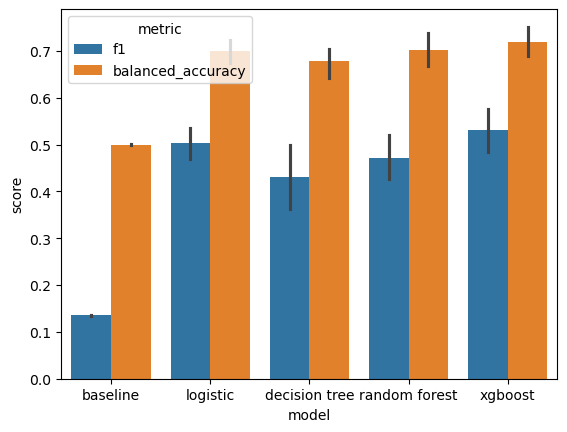

In [10]:
import seaborn as sns
f1_scores = {
    "baseline": baseline_f1s,
    "logistic": logistic_cv["test_f1"],
    "decision tree": dt_cv["test_f1"],
    "random forest": rf_cv["test_f1"],
    "xgboost": xgb_cv["test_f1"],
}
balanced_accuracy_scores = {
    "baseline": baseline_balanced_accuracy,
    "logistic": logistic_cv["test_balanced_accuracy"],
    "decision tree": dt_cv["test_balanced_accuracy"],
    "random forest": rf_cv["test_balanced_accuracy"],
    "xgboost": xgb_cv["test_balanced_accuracy"],
}
performance = pd.concat([
    pd.DataFrame({
        "model": k,
        "metric": "f1",
        "score": v
    })
    for (k, v) in f1_scores.items()
] + [
    pd.DataFrame({
        "model": k,
        "metric": "balanced_accuracy",
        "score": v
    })
    for (k, v) in balanced_accuracy_scores.items()
])

score_plot = sns.barplot(data=performance, x="model", y="score", hue="metric")
# f1_plot.set_ylabel(r"$F_1$")
sns.move_legend(score_plot, "upper left")

All of our tested models perform comparibly and all out perform the baseline model.

- **Balanced Accuracy**: Models outperform the baseline by about a factor of 1.4 (0.7 vs 0.5)
- **$F_1$ Score**: Models outperform the baseline by more than a factor of 3 (0.5 vs 0.15)

Given that we care about true negatives less than true positives, we decided to use $F_1$ score as the metric for choosing our best model.

In this case, by a narrow margin, the best model is **XGBoost**.

Text(0, 0.5, '$F_1$')

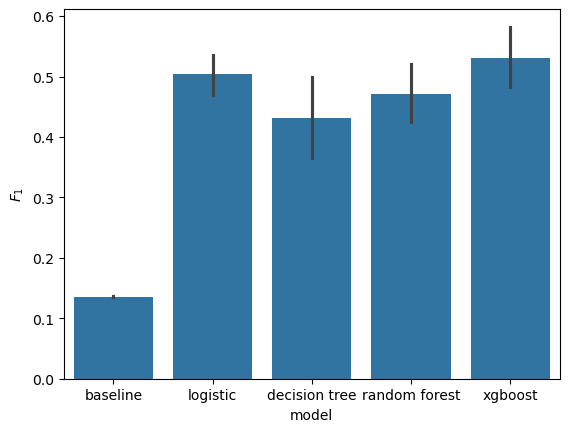

In [11]:
f1_plot = sns.barplot(data=performance[performance["metric"] == "f1"], x="model", y="score")
f1_plot.set_ylabel(r"$F_1$")